# Part 2: Bias audit

High-black (`black` ≥ 0.5) vs reference (`black` < 0.1 and `white` ≥ 0.5).


In [1]:
import subprocess, sys
for p in ["aif360", "matplotlib", "seaborn", "pandas", "numpy", "scikit-learn"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])
print("OK")


All packages ready.


In [ ]:
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "aif360[Reductions]", "aif360[inFairness]"])


0

In [2]:
import os
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import ClassificationMetric

CHECKPOINT_DIR = "/content/drive/My Drive/Colab Notebooks/distilbert_toxic_checkpoint"
THRESHOLD = 0.40
print(f"{CHECKPOINT_DIR=} {THRESHOLD=}")


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


Imports done.
Operating threshold : 0.4


In [4]:
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [5]:
CHECKPOINT_DIR = "/content/drive/My Drive/Colab Notebooks/distilbert_toxic_checkpoint"
print(sorted(os.listdir(CHECKPOINT_DIR))[:20], "…", len(os.listdir(CHECKPOINT_DIR)))


Files in checkpoint: ['config.json', 'tokenizer_config.json', 'tokenizer.json', 'training_args.bin', 'model.safetensors', 'checkpoint-6250', 'checkpoint-3125', 'checkpoint-9375', 'eval_probs.npy', 'eval_labels.npy', 'eval_df.parquet']


In [10]:
prob_toxic = np.load(os.path.join(CHECKPOINT_DIR, "eval_probs.npy"))
true_labels = np.load(os.path.join(CHECKPOINT_DIR, "eval_labels.npy"))
df_eval = pd.read_parquet(os.path.join(CHECKPOINT_DIR, "eval_df.parquet"))
df_eval["prob_toxic"] = prob_toxic
df_eval["pred_label"] = (prob_toxic >= THRESHOLD).astype(int)
df_eval["true_label"] = true_labels.astype(int)
print(len(df_eval), df_eval.columns.tolist())
df_eval[["comment_text", "black", "white", "true_label", "pred_label"]].head()


Eval set size : 20,000 rows
Columns       : ['comment_text', 'toxic', 'black', 'jewish', 'muslim', 'other_sexual_orientation', 'white', 'label', 'prob_toxic', 'pred_label', 'true_label']

Sample:


,comment_text,black,white,true_label,pred_label
0,"In Sitka, and other SE communities there is in...",NaN,NaN,0,0
1,Trump lies an average of 7 times a day and the...,NaN,NaN,1,0
2,"Sure. When someone breaks into my home, I'll j...",NaN,NaN,0,0
3,Undoubtedly the failed parents who inadequatel...,0.0,0.0,0,0
4,"Oh, for heaven's sake. This is good news for ...",NaN,NaN,0,0
5,I thought you were cracking a joke until I saw...,NaN,NaN,0,0
6,You are attempting to justify name calling in ...,NaN,NaN,0,0
7,"""Can Donald Trump fix his relationship with bl...",1.0,0.0,0,0
8,I don't dispute the numbers... I'm referring t...,0.0,0.0,0,0
9,No on the income tax. People can come up with...,NaN,NaN,0,0


In [11]:
print("n high-black:", int((df_eval["black"] >= 0.5).sum()))
print("n reference:", int(((df_eval["black"] < 0.1) & (df_eval["white"] >= 0.5)).sum()))


--- Rows where 'black' >= 0.5 ---
                                            comment_text     toxic  black  \
7      "Can Donald Trump fix his relationship with bl...  0.200000    1.0   
90     Wiliki, there are many methodological issues w...  0.166667    0.5   
197    Uh oh.  The Repugnicans are divided between th...  0.000000    0.5   
804    Comparing trump to Roosevelt or Lincoln on any...  0.000000    0.8   
933    His Grandfather was a draft dodger, pimp and a...  0.166667    0.8   
...                                                  ...       ...    ...   
19697  Your "black on black violence" theme outs you,...  0.400000    0.8   
19744  You're evidently against the man because he's ...  0.615385    1.0   
19929  Before moving to tiny-minded Eugene, (which ha...  0.000000    1.0   
19978  Flagged ?  For defending my civil rights as a ...  0.500000    1.0   
19989  Black-hearted, please.  Leave Black Catholics ...  0.300000    1.0   

       jewish  muslim  other_sexual_orien

In [12]:
for c in ("black", "white"):
    df_eval[c] = df_eval[c].fillna(0.0)
df_black = df_eval[df_eval["black"] >= 0.5].copy()
df_white = df_eval[(df_eval["black"] < 0.1) & (df_eval["white"] >= 0.5)].copy()
print(len(df_black), len(df_white), df_black["true_label"].mean(), df_white["true_label"].mean())


  COHORT SIZES
  High-black cohort : 164 rows
  Reference cohort  : 196 rows

High-black toxic rate : 0.274
Reference  toxic rate : 0.270


In [13]:
def cohort_metrics(df, name):
    y_t, y_p = df["true_label"].values, df["pred_label"].values
    tn, fp, fn, tp = confusion_matrix(y_t, y_p, labels=[0, 1]).ravel()
    tpr = tp / (tp + fn) if (tp + fn) else 0.0
    fpr = fp / (fp + tn) if (fp + tn) else 0.0
    fnr = fn / (fn + tp) if (fn + tp) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    return {"Cohort": name, "N": len(df), "TPR": round(tpr, 4), "FPR": round(fpr, 4),
            "FNR": round(fnr, 4), "Precision": round(prec, 4), "_cm": (tn, fp, fn, tp)}

mb, mw = cohort_metrics(df_black, "High-Black"), cohort_metrics(df_white, "Reference")


Cohort metrics computed.


In [14]:
di = mb["FPR"] / mw["FPR"] if mw["FPR"] > 0 else float("inf")
summary = pd.DataFrame([{k: v for k, v in mb.items() if k != "_cm"},
                        {k: v for k, v in mw.items() if k != "_cm"}])
print(summary.to_string(index=False))
print(f"disparate_impact FPR ratio = {di:.4f}")


  PER-COHORT FAIRNESS METRICS
           Cohort   N    TPR    FPR    FNR  Precision
       High-Black 164 0.5778 0.1513 0.4222     0.5909
Reference (White) 196 0.5849 0.0769 0.4151     0.7381

  Disparate Impact Ratio (FPR_black / FPR_white) : 1.9675
  → Model over-flags the High-Black cohort by 96.7%


In [16]:
df_b = df_black[["true_label", "pred_label"]].assign(group=1)
df_w = df_white[["true_label", "pred_label"]].assign(group=0)
comb = pd.concat([df_b, df_w], ignore_index=True)

ds_t = BinaryLabelDataset(
    df=comb[["true_label", "group"]].rename(columns={"true_label": "label"}),
    label_names=["label"],
    protected_attribute_names=["group"],
    favorable_label=0,
    unfavorable_label=1,
)
ds_p = BinaryLabelDataset(
    df=comb[["pred_label", "group"]].rename(columns={"pred_label": "label"}),
    label_names=["label"],
    protected_attribute_names=["group"],
    favorable_label=0,
    unfavorable_label=1,
)
m = ClassificationMetric(ds_t, ds_p, unprivileged_groups=[{"group": 1}], privileged_groups=[{"group": 0}])
spd, eod = m.statistical_parity_difference(), m.equal_opportunity_difference()
print(f"SPD={spd:.4f}  EOD={eod:.4f}")


Imports done.
Operating threshold : 0.4
  aif360 FAIRNESS METRICS
  Statistical Parity Difference  : -0.0540
  Equal Opportunity Difference   : -0.0743
  Ideal values for both metrics = 0.0
  Negative SPD → black cohort predicted toxic MORE often
  Negative EOD → black cohort has LOWER TPR (missed more)


Fairness metrics above quantify cohort-level **TPR / FPR / FNR** disparities; **SPD** and **EOD** summarize group differences in predicted vs true positive rates. Relate gaps to operational harm (over-moderation vs missed abuse).


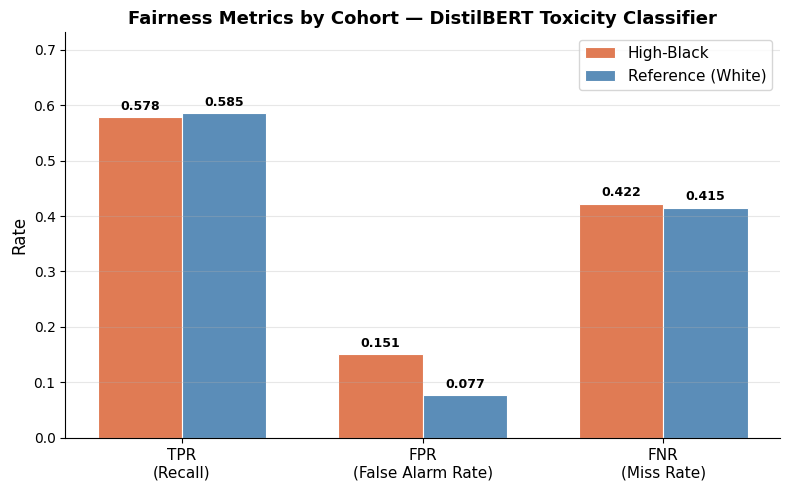

In [17]:
metrics_list = ["TPR", "FPR", "FNR"]
black_vals = [mb[m] for m in metrics_list]
white_vals = [mw[m] for m in metrics_list]
x, w = np.arange(len(metrics_list)), 0.35
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - w / 2, black_vals, w, label="High-Black", color="#E07B54", edgecolor="white", linewidth=0.8)
ax.bar(x + w / 2, white_vals, w, label="Reference", color="#5B8DB8", edgecolor="white", linewidth=0.8)
for bars in (ax.containers[0], ax.containers[1]):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.008, f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_xticks(x, ["TPR
(recall)", "FPR
(false alarm)", "FNR
(miss)"])
ax.set_ylabel("Rate")
ax.set_title("Fairness metrics by cohort")
ax.set_ylim(0, max(black_vals + white_vals) * 1.25)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()


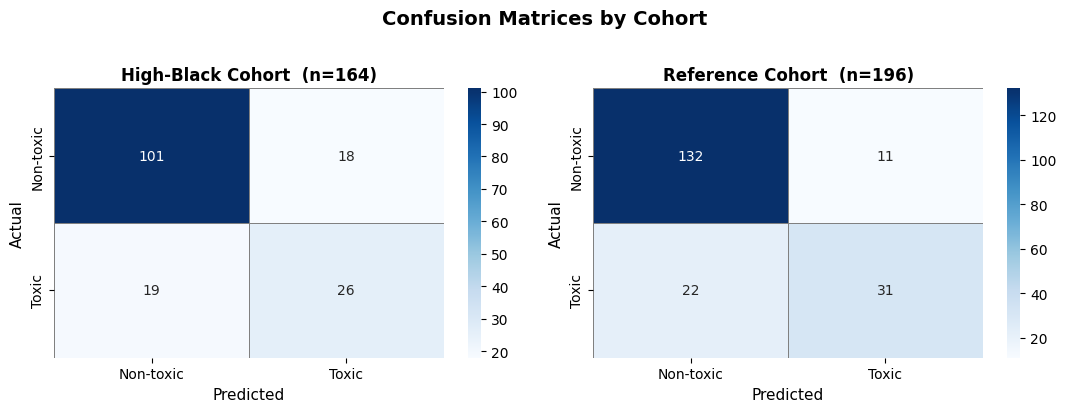

In [18]:
def plot_cm(cm, title, ax):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["Non-toxic", "Toxic"], yticklabels=["Non-toxic", "Toxic"], linewidths=0.5, linecolor="gray")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(title, fontweight="bold")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tn, fp, fn, tp = mb["_cm"]
plot_cm(np.array([[tn, fp], [fn, tp]]), f"High-Black (n={len(df_black):,})", axes[0])
tn, fp, fn, tp = mw["_cm"]
plot_cm(np.array([[tn, fp], [fn, tp]]), f"Reference (n={len(df_white):,})", axes[1])
plt.suptitle("Confusion matrices by cohort", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


## Discussion

Largest gaps usually show up in **FPR** or **FNR**, depending on threshold and base rates. **SPD / EOD** compress those effects into single bias statistics—use cohort rates for narrative, metrics for summary.
